CNN Thật:
```
8 Filters
↓
8 Feature Maps

32 Filters
↓
32 Feature Maps

64 Filters
↓
64 Feature Maps
```

Mục tiêu notebook:
```
8 Filters
↓
8 Feature Maps

32 Filters
↓
32 Feature Maps

64 Filters
↓
64 Feature Maps
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.convolution import Convolution2D

from src.utils import (
    load_image,
    show_image,
    plot_feature_maps,
    plot_filters
)

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("07 - MULTI FILTERS")
print("=" * 60)

CNN FROM SCRATCH
07 - MULTI FILTERS


Part 1 - One Filter

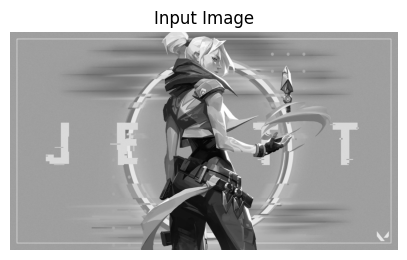

In [3]:
image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

show_image(
    image,
    "Input Image"
)

In [4]:
conv = Convolution2D(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=1
)

feature_map = conv.forward(image)

print(
    feature_map.shape
)

(1, 1080, 1920)


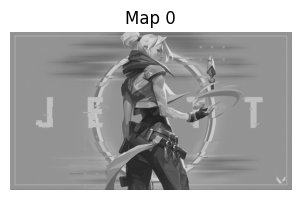

In [5]:
plot_feature_maps(
    feature_map,
    max_maps=1
)

Part 2 - Four Filters

In [6]:
conv = Convolution2D(
    in_channels=1,
    out_channels=4,
    kernel_size=3,
    padding=1
)

feature_maps = conv.forward(
    image
)

print(
    feature_maps.shape
)

(4, 1080, 1920)


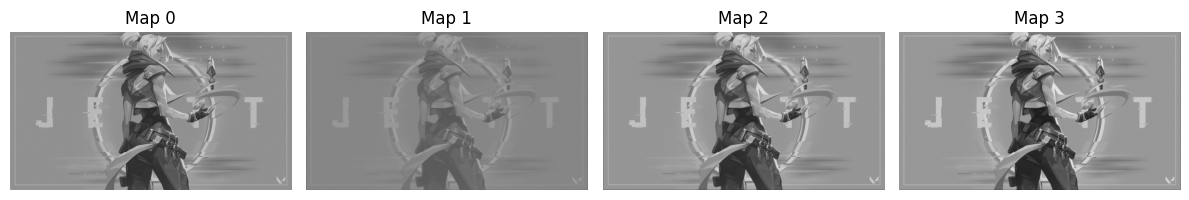

In [7]:
plot_feature_maps(
    feature_maps,
    max_maps=4
)

Part 3 - Eight Filters

In [8]:
conv = Convolution2D(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    padding=1
)

feature_maps = conv.forward(
    image
)

print(
    feature_maps.shape
)

(8, 1080, 1920)


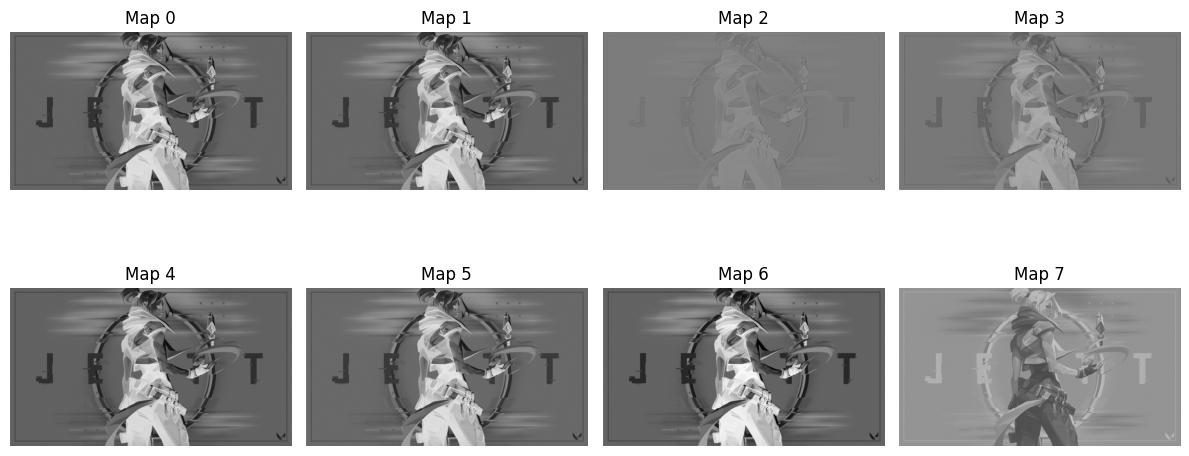

In [9]:
plot_feature_maps(
    feature_maps,
    max_maps=8
)

Part 4 - Visualize Filters

In [10]:
print(
    conv.filters.shape
)

(8, 1, 3, 3)


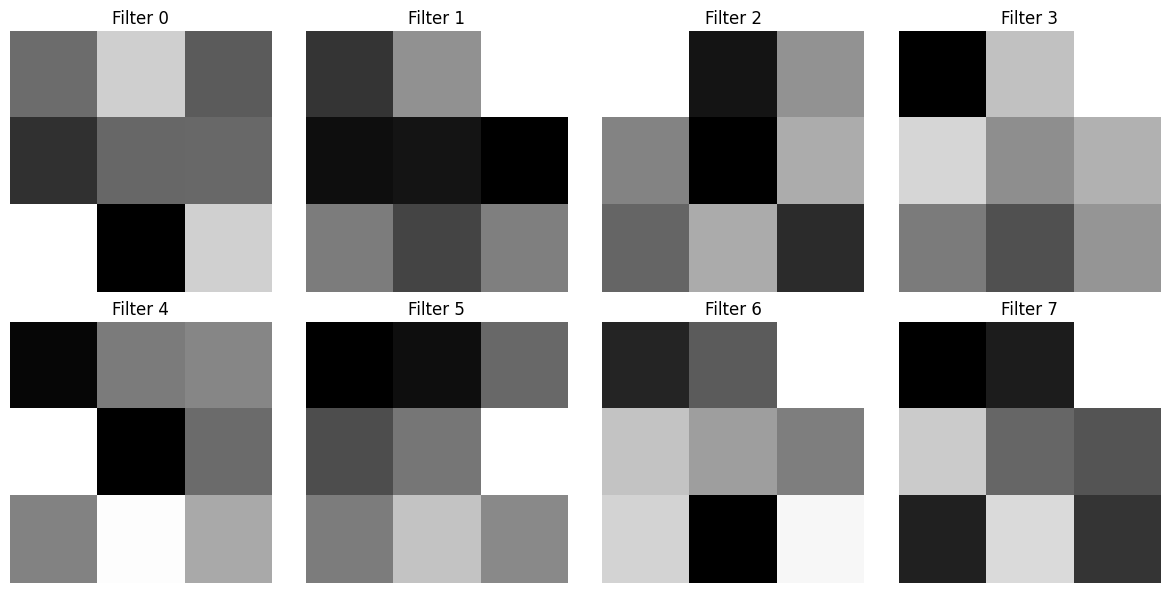

In [11]:
plot_filters(
    conv.filters
)

Part 5 - Filter Parameters

In [12]:
print(
    "Filter Shape:",
    conv.filters.shape
)

Filter Shape: (8, 1, 3, 3)


In [13]:
num_weights = conv.filters.size

num_bias = conv.bias.size

print(
    "Weights:",
    num_weights
)

print(
    "Bias:",
    num_bias
)

print(
    "Total:",
    num_weights + num_bias
)

Weights: 72
Bias: 8
Total: 80


In [14]:
F = 8
C = 1
K = 3

parameters = (
    F * C * K * K
) + F

print(parameters)

80


Part 6 - RGB Image Example

In [15]:
rgb_image = load_image(
    "../data/sample.jpg",
    grayscale=False
)

print(
    rgb_image.shape
)

(3, 1080, 1920)


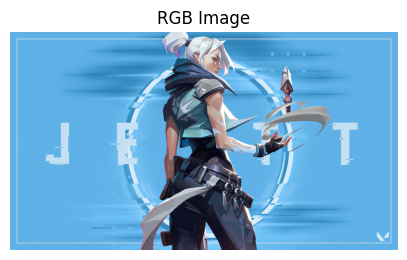

In [16]:
show_image(
    rgb_image,
    "RGB Image"
)

In [17]:
conv_rgb = Convolution2D(
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    padding=1
)

feature_maps_rgb = (
    conv_rgb.forward(
        rgb_image
    )
)

print(
    feature_maps_rgb.shape
)

(8, 1080, 1920)


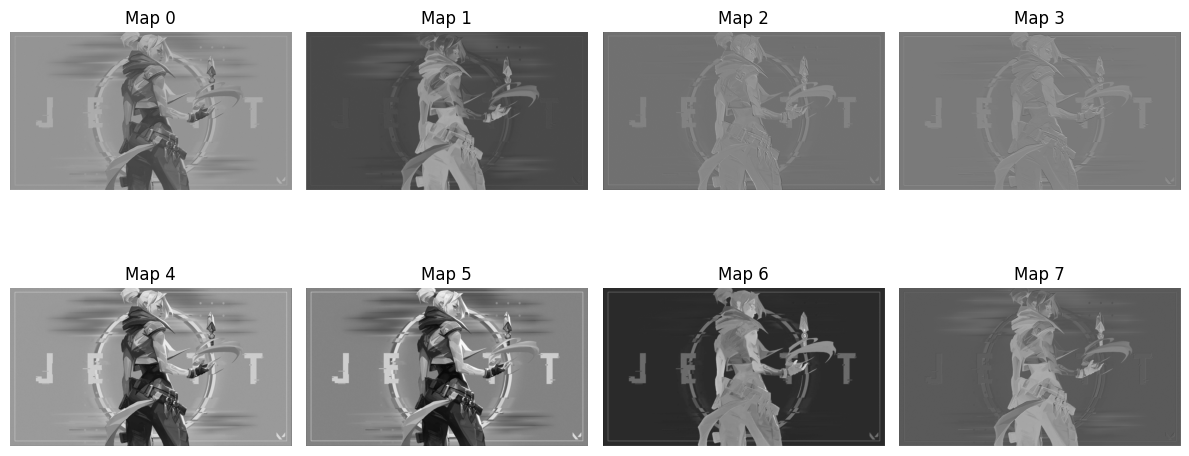

In [18]:
plot_feature_maps(
    feature_maps_rgb,
    max_maps=8
)

Part 7 - What Does One RGB Filter Look Like?

In [19]:
kernel = conv_rgb.filters[0]

print(
    kernel.shape
)

(3, 3, 3)


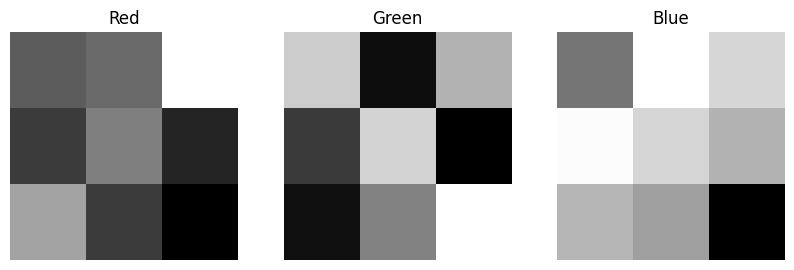

In [20]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(10,3)
)

titles = [
    "Red",
    "Green",
    "Blue"
]

for i in range(3):

    ax[i].imshow(
        kernel[i],
        cmap="gray"
    )

    ax[i].set_title(
        titles[i]
    )

    ax[i].axis("off")

plt.show()

An RGB filter contains

3 kernels

One for each channel:
- Red
- Green
- Blue

Part 8 - Feature Explosion

```
Classic CNN

Input
 ↓
32 Filters

 ↓

32 Feature Maps

Deeper Layer

32 Input Maps

↓

64 Filters

↓

64 Output Maps
```

In [21]:
F = 64
C = 32
K = 3

params = (
    F * C * K * K
) + F

print(
    f"{params:,}"
)

18,496


Part 9 - Simulate Edge Detectors

In [22]:
vertical_kernel = np.array(
[
[-1,0,1],
[-1,0,1],
[-1,0,1]
],
dtype=np.float32
)

print(vertical_kernel)

[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]


In [23]:
horizontal_kernel = np.array(
[
[-1,-1,-1],
[ 0, 0, 0],
[ 1, 1, 1]
],
dtype=np.float32
)

print(horizontal_kernel)

[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]


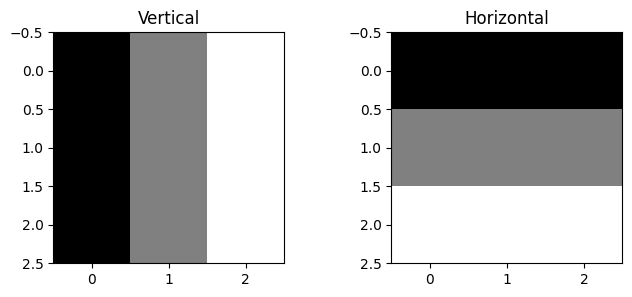

In [24]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(
    vertical_kernel,
    cmap="gray"
)
plt.title("Vertical")

plt.subplot(1,2,2)
plt.imshow(
    horizontal_kernel,
    cmap="gray"
)
plt.title("Horizontal")

plt.show()

CNN Representation Learning

```
Raw Pixels

↓

Edges

↓

Textures

↓

Shapes

↓

Object Parts

↓

Objects

↓

Prediction
```